In [15]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
def normalize(X):
    m_mean = X.mean(axis=0)
    m_std = X.std(axis=0)
    return (X - m_mean) / m_std

In [17]:
data=pd.read_csv("../datasets/gold-monthly.csv")
X_int = data["Date"].str.replace("-", "").astype(int).values
X=torch.tensor(normalize(X_int), dtype=torch.double).squeeze()
Y=torch.tensor(normalize(data[["Price"]].values), dtype=torch.double).squeeze()

In [18]:
class polynomial_regression(torch.nn.Module):

    def __init__(self, degree):
        super().__init__()
        self.coeffs = torch.nn.Parameter(torch.randn(degree + 1))

    def forward(self, x):
        y = 0
        for i in range(len(self.coeffs)):
            y += self.coeffs[i] * x**i
        return y

In [19]:
model = polynomial_regression(degree=8)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()

In [20]:
for epoch in range(10000):
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 339.1687537430227
Epoch 1000, Loss: 0.2507617311119268
Epoch 2000, Loss: 0.2065116439546762
Epoch 3000, Loss: 0.1800984511836348
Epoch 4000, Loss: 0.16092051455105313
Epoch 5000, Loss: 0.14640547157920178
Epoch 6000, Loss: 0.13523797314035463
Epoch 7000, Loss: 0.12654830352401908
Epoch 8000, Loss: 0.1197157645894081
Epoch 9000, Loss: 0.11428760192006547


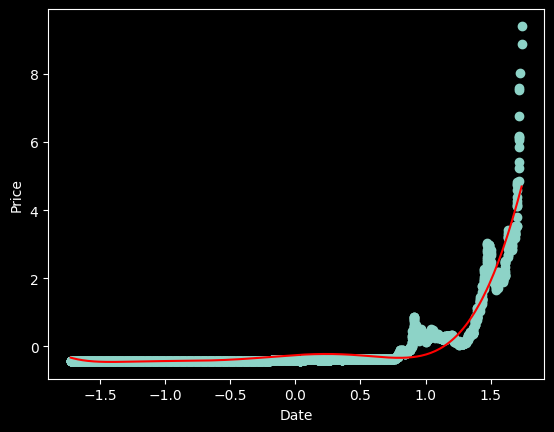

In [21]:
plt.scatter(X, Y)
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot(X.detach().numpy(), model.forward(X).detach().numpy() , color="red")
plt.show()